# Coming from matplotlib

pyplotrs looks like matplotlib where matplotlib got it right, and deliberately
differs where a second attempt can do better. This notebook is both halves of
that: **the API differences**, so you can port a script without guessing, and
**the same data rendered by both libraries side by side**, so you can see what
actually changes on the page.

> **Naming.** `plt` is matplotlib — the import you already have in your fingers
> — and pyplotrs is `pp`. That is the convention throughout these docs, not a
> local dodge: the two names mean two different libraries, so a snippet says
> which one it is without a caption. Here it also lets both be on screen at
> once.

This is the one notebook here that needs matplotlib and NumPy installed
(`pip install matplotlib numpy`); they are used for the reference renders and
for stitching the comparison images together, never by pyplotrs itself.

In [1]:
import io
import math
import random
import tempfile
from pathlib import Path

# `plt` is matplotlib - the import already in your fingers - and pyplotrs is
# `pp`, as everywhere in these docs. Two names, two libraries, so both can be
# on screen at once with nothing to disambiguate.
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pyplotrs as pp

%matplotlib inline

# --- Making the comparison fair -------------------------------------------
#
# Same data, same canvas, same pixel density. pyplotrs sizes in points, so the
# matplotlib references convert (72 pt = 1 in), and both render at 150 dpi -
# the density pyplotrs uses for inline display.
DPI = 150
SIZE_PT = (220, 170)

plt.rcParams["figure.dpi"] = DPI
plt.rcParams["savefig.dpi"] = DPI

# Every matplotlib reference below is built with `layout="constrained"`, which
# is the closest thing it has to what pyplotrs does unasked. Without it a
# colorbar label or a long tick runs off the canvas, and a comparison that clips
# one side's labels is not a comparison.
CONSTRAINED = {"layout": "constrained"}

# Each library keeps its own default typeface, and that difference is one of
# the things being compared: matplotlib ships and uses DejaVu Sans, while
# pyplotrs asks the host for Arial, then Helvetica, and falls back to the
# Liberation Sans compiled into it. So the labels below differ because the
# defaults differ - and the pyplotrs half shows whichever face this machine
# resolved, printed underneath.

print("pyplotrs body font:", pp.resolved_font_name())
print("pyplotrs", pp.__version__, "· matplotlib", matplotlib.__version__)

pyplotrs body font: Arial
pyplotrs 0.1.0 · matplotlib 3.11.0


In [2]:
def pt2in(size=SIZE_PT):
    """pyplotrs sizes in points; matplotlib wants inches."""
    return (size[0] / 72, size[1] / 72)


SCRATCH = Path(tempfile.mkdtemp(prefix="pyplotrs-compare-"))


def _as_array(fig):
    """Render either library's figure to an RGBA pixel array at DPI."""
    if isinstance(fig, plt.Figure):
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=DPI)
        plt.close(fig)          # or the inline backend shows it a second time
    else:
        # pyplotrs writes files rather than streams; `save` picks PNG from the
        # extension, and `dpi` is the same knob matplotlib's `savefig` takes.
        png = SCRATCH / "panel.png"
        fig.save(str(png), dpi=DPI)
        buf = io.BytesIO(png.read_bytes())
    buf.seek(0)
    return plt.imread(buf)


def compare(pyplotrs_fig, matplotlib_fig, gap=24, band=22):
    """Stitch the two renders into one captioned image, pyplotrs on the left."""
    panels = [(_as_array(pyplotrs_fig), "pyplotrs"),
              (_as_array(matplotlib_fig), "matplotlib")]

    width = sum(img.shape[1] for img, _ in panels) + gap
    height = max(img.shape[0] for img, _ in panels) + band
    sheet = plt.figure(figsize=(width / DPI, height / DPI), dpi=DPI, facecolor="white")

    x = 0.0
    for img, caption in panels:
        w, h = img.shape[1] / width, img.shape[0] / height
        ax = sheet.add_axes([x, 0.0, w, h])
        ax.imshow(img, interpolation="none")
        ax.axis("off")
        sheet.text(x + w / 2, 1 - (band / height) / 2, caption, ha="center",
                   va="center", fontsize=9, color="#555555")
        x += w + gap / width

    # Hand the figure back as the cell's value so it displays exactly once:
    # left open, the inline backend would flush it as a second copy.
    plt.close(sheet)
    return sheet


# One seeded set of numbers, fed to both libraries, with no NumPy in sight:
# pyplotrs takes any iterable of numbers and has no array dependency.
random.seed(11)
t = [i * 0.1 for i in range(81)]
sine = [math.sin(x) for x in t]
decay = [math.sin(x) * math.exp(-0.15 * x) for x in t]
groups = ["ash", "birch", "cedar", "elm"]
counts = [12.0, 19.0, 7.5, 15.2]
samples = [random.gauss(0.0, 1.0) for _ in range(400)]
print("data ready")

data ready


## The five differences that matter

### 1 · There is no pyplot state machine

No current figure, no current axes, no `plt.plot(...)` at module level, no
`plt.show()`. `subplots` hands you objects and you keep them.

```python
# matplotlib                       # pyplotrs
import matplotlib.pyplot as plt    import pyplotrs as pp
plt.plot(xs, ys)                   fig, ax = pp.subplots()
plt.xlabel("x")                    ax.line(xs, ys)
plt.savefig("out.png")             ax.set(xlabel="x")
                                   fig.save("out.png")
```

Everything else follows from it: a function that builds a figure returns it, two
figures never interfere, and two threads are safe by construction.

### 2 · `set(**kwargs)` replaces the whole setter family

There is no `set_xlabel` / `set_xlim` / `set_xscale` / `set_xticks`. One method
writes an axes, and the `get_*` accessors read back the **effective** value.

### 3 · `line`, not `plot`

The 2D line mark is `line`. (`plot` *is* the name on polar and 3D axes, where
there is nothing to disambiguate it from.)

### 4 · One name per concept, one unit per quantity

- A stroke width is **`linewidth`** everywhere. No `lw`; `width` only ever means
  an extent in data units, like a bar's thickness.
- Marker size is **`markersize`**, a *diameter in points*, on every mark
  including `scatter`. matplotlib's `s` (an area in pt²) is accepted as `size=`,
  so `size=36` and `markersize=6` mean the same thing.
- `alpha` and `zorder` are accepted on every mark, not on a subset of them.

### 5 · `fig.save(path)`, with the format from the extension

```python
fig.save("out.pdf")                  # not fig.savefig(...)
fig.save("out.png", dpi=300)
fig.save("out.html")                 # matplotlib has no equivalent
fig.save("out.pdf", tagged=True)     # accessible, tagged PDF
```

## Translation table

| matplotlib | pyplotrs |
|---|---|
| `plt.subplots(...)` | `pp.subplots(...)` — same signature, plus `theme=`, `units=` |
| `ax.plot(x, y)` | `ax.line(x, y)` |
| `ax.plot(x, y, "o")` | `ax.line(x, y, marker="o", linestyle="none")` or `ax.scatter(x, y)` |
| `ax.scatter(x, y, s=36)` | `ax.scatter(x, y, markersize=6)` (or `size=36`) |
| `ax.set_xlabel("x")` | `ax.set(xlabel="x")` |
| `ax.set_xlim(0, 1)` | `ax.set(xlim=(0, 1))` |
| `ax.set_xscale("log")` | `ax.set(xscale="log")` |
| `ax.set_xticks([...])` | `ax.set(xticks=[...])` |
| `ax.set_xticklabels([...])` | `ax.set(xticklabels=[...])` |
| `ax.grid(True)` | `ax.set(grid=True)` |
| `ax.tick_params(direction="in")` | `ax.set(tick_direction="in")` |
| `ax.xaxis.set_major_formatter(f)` | `ax.set(xformatter=f)` |
| `ax.margins(0.2)` | `ax.set(margin=0.2)` |
| `ax.invert_yaxis()` | `ax.set(yinverted=True)` |
| `ax.set_aspect("equal")` | `ax.set(aspect="equal")` |
| `fig.suptitle("…")` | `fig.set(suptitle="…")` |
| `fig.savefig("f.png", dpi=300)` | `fig.save("f.png", dpi=300)` |
| `fig.tight_layout()` | *not needed* — layout is solved before drawing |
| `plt.style.use("seaborn")` | `pp.subplots(theme="dark")` or a `Theme` |
| `rcParams["font.sans-serif"]` | `pp.set_font_family(...)` |
| `ax.plot_surface(X, Y, Z)` | `ax.surface(X, Y, Z)` |
| `ax.pcolor` / `pcolormesh` | same names |
| `plt.show()` | — (a `Figure` displays itself in a notebook) |

`label=` / `legend()`, `hlines` vs `axhline`, `fill_between`, `errorbar`,
`imshow` + `colorbar`, `twinx`, `inset_axes`, `subplot_mosaic`, `GridSpec`
slicing and the `where=` argument of `step` all behave as you expect.

## The same figure, both ways

Here is difference 1, 2, 3 and 5 in one cell — the identical plot written twice.

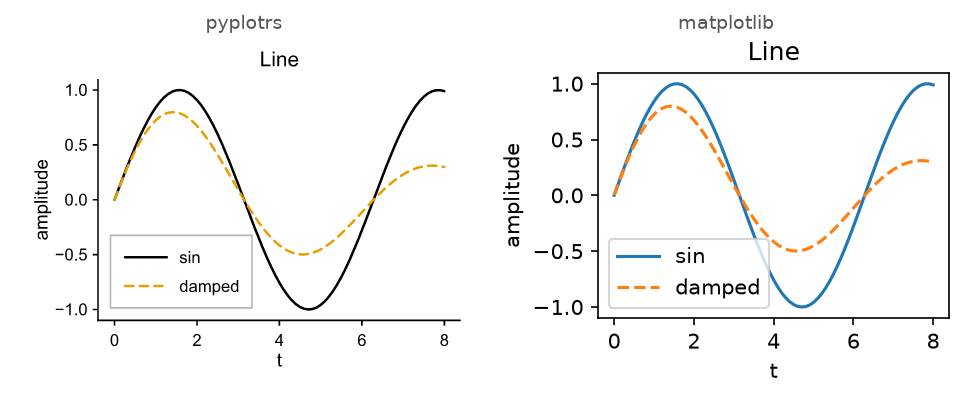

In [3]:
# ---- pyplotrs -------------------------------------------------------------
fig_pp, ax = pp.subplots(figsize=SIZE_PT)
ax.line(t, sine, label="sin")
ax.line(t, decay, label="damped", linestyle="dashed")
ax.set(title="Line", xlabel="t", ylabel="amplitude")
ax.legend()

# ---- matplotlib -----------------------------------------------------------
fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
ax.plot(t, sine, label="sin")
ax.plot(t, decay, label="damped", linestyle="dashed")
ax.set(title="Line", xlabel="t", ylabel="amplitude")
ax.legend()

compare(fig_pp, fig_mp)

Same data, same canvas — and four defaults differ on purpose:

- **Two spines, not four.** The top and right spines carry no information, so
  they are off by default (`theme=...with_(spines=(...))` puts them back).
- **A colorblind-safe palette.** The cycle is Okabe-Ito, not `tab10`.
- **A real minus sign.** Tick labels use U+2212, not the hyphen-minus.
- **Tighter chrome.** Tick and label sizes are set for a journal column, which
  is what the default 250 × 200 pt canvas is.

## The rest of the vocabulary, side by side

Nothing below is styled. Every pair is the default output of both libraries on
the same numbers.

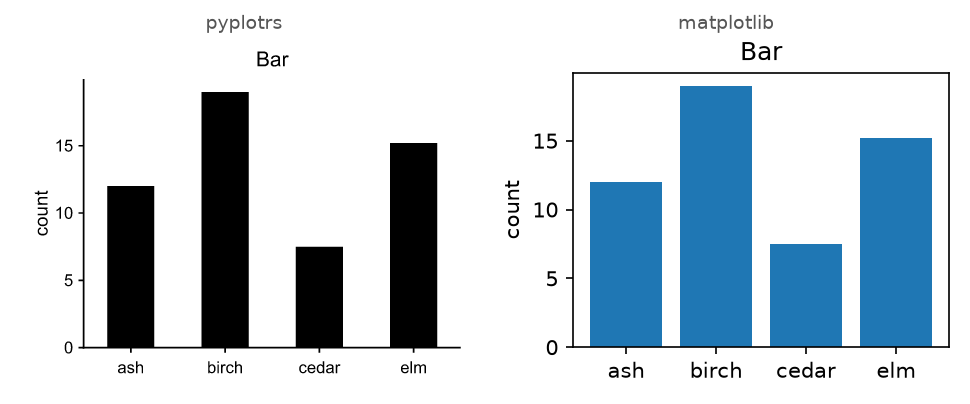

In [4]:
# Bars over categories. pyplotrs puts the strings on the axis directly.
fig_pp, ax = pp.subplots(figsize=SIZE_PT)
ax.bar(groups, counts)
ax.set(title="Bar", ylabel="count")

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
ax.bar(groups, counts)
ax.set(title="Bar", ylabel="count")

compare(fig_pp, fig_mp)

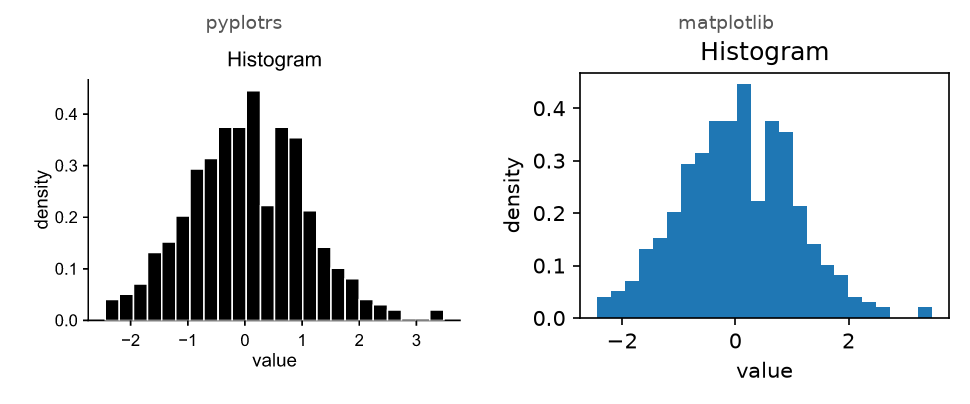

In [5]:
# Histogram. `bins` and `density` mean the same in both.
fig_pp, ax = pp.subplots(figsize=SIZE_PT)
ax.hist(samples, bins=24, density=True)
ax.set(title="Histogram", xlabel="value", ylabel="density")

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
ax.hist(samples, bins=24, density=True)
ax.set(title="Histogram", xlabel="value", ylabel="density")

compare(fig_pp, fig_mp)

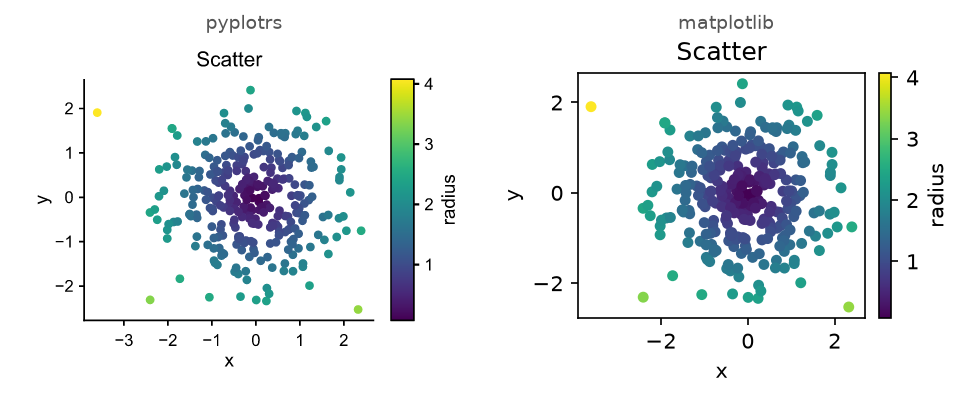

In [6]:
# Scatter with a third variable in color, and a colorbar.
# The only rename: matplotlib's `s=` (an area in pt²) is `size=` here.
random.seed(3)
sx = [random.gauss(0.0, 1.0) for _ in range(300)]
sy = [random.gauss(0.0, 1.0) for _ in range(300)]
radius = [math.hypot(x, y) for x, y in zip(sx, sy)]

fig_pp, ax = pp.subplots(figsize=SIZE_PT)
mark = ax.scatter(sx, sy, c=radius, size=18)
fig_pp.colorbar(mark, label="radius")
ax.set(title="Scatter", xlabel="x", ylabel="y")

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
mark = ax.scatter(sx, sy, c=radius, s=18)
fig_mp.colorbar(mark, ax=ax, label="radius")
ax.set(title="Scatter", xlabel="x", ylabel="y")

compare(fig_pp, fig_mp)

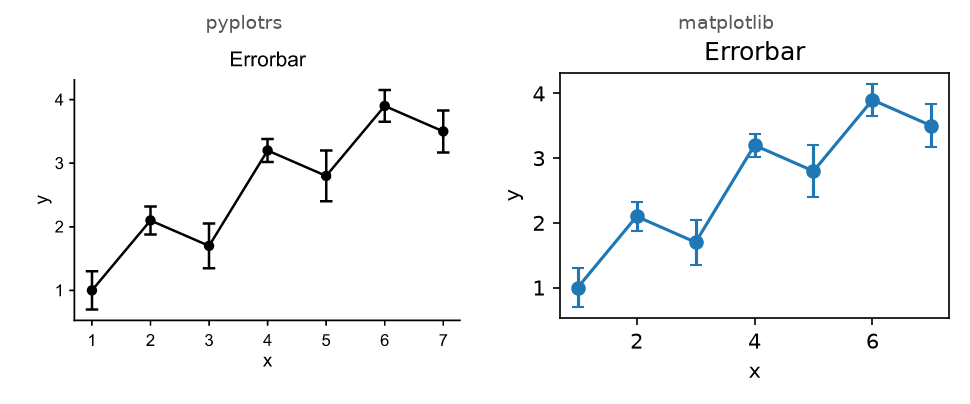

In [7]:
# Error bars. pyplotrs draws markers and caps by default; matplotlib needs both
# asked for, which is the "one name per concept" rule showing up as a default.
x_err = list(range(1, 8))
y_err = [1.0, 2.1, 1.7, 3.2, 2.8, 3.9, 3.5]
err = [0.30, 0.22, 0.35, 0.18, 0.40, 0.25, 0.33]

fig_pp, ax = pp.subplots(figsize=SIZE_PT)
ax.errorbar(x_err, y_err, yerr=err)
ax.set(title="Errorbar", xlabel="x", ylabel="y")

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
ax.errorbar(x_err, y_err, yerr=err, marker="o", capsize=3)
ax.set(title="Errorbar", xlabel="x", ylabel="y")

compare(fig_pp, fig_mp)

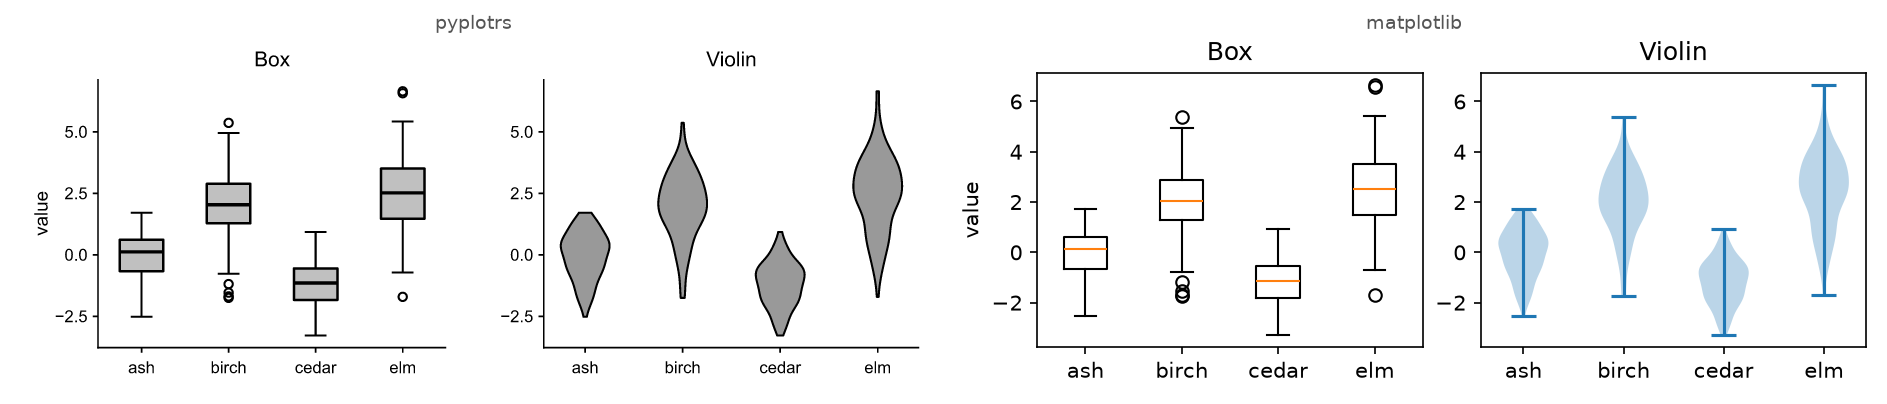

In [8]:
# Box and violin over the same four distributions.
random.seed(7)
dists = [[random.gauss(mu, sd) for _ in range(120)]
         for mu, sd in ((0.0, 1.0), (1.8, 1.3), (-1.2, 0.8), (2.5, 1.6))]
positions = [1, 2, 3, 4]

fig_pp, axs = pp.subplots(1, 2, figsize=(2 * SIZE_PT[0], SIZE_PT[1]))
axs[0].boxplot(dists, positions=positions)
axs[0].set(title="Box", xticks=positions, xticklabels=groups, ylabel="value")
axs[1].violinplot(dists, positions=positions)
axs[1].set(title="Violin", xticks=positions, xticklabels=groups)

fig_mp, axs = plt.subplots(1, 2, figsize=pt2in((2 * SIZE_PT[0], SIZE_PT[1])),
                           **CONSTRAINED)
axs[0].boxplot(dists, positions=positions)
axs[0].set(title="Box", ylabel="value")
axs[0].set_xticks(positions, groups)
axs[1].violinplot(dists, positions=positions)
axs[1].set(title="Violin")
axs[1].set_xticks(positions, groups)

compare(fig_pp, fig_mp)

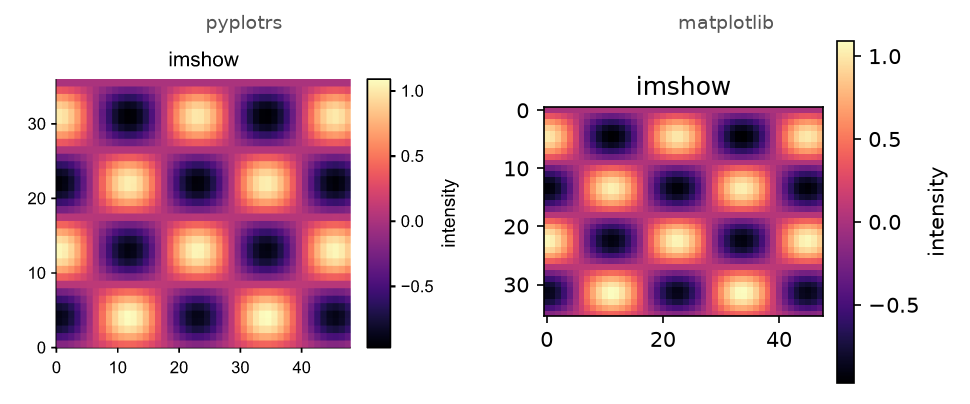

In [9]:
# An image with a colorbar. Plain nested lists on both sides.
field = [[math.sin(0.35 * i) * math.cos(0.28 * j) + 0.1 * i / 30
          for j in range(48)] for i in range(36)]

fig_pp, ax = pp.subplots(figsize=SIZE_PT)
image = ax.imshow(field, cmap="magma")
fig_pp.colorbar(image, label="intensity")
ax.set(title="imshow")

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
image = ax.imshow(field, cmap="magma")
fig_mp.colorbar(image, ax=ax, label="intensity")
ax.set(title="imshow")

compare(fig_pp, fig_mp)

One difference there is worth having in your fingers before you port a script
that draws on top of an image: with the default `origin="upper"` both libraries
put row 0 at the **top**, but matplotlib expresses that by *inverting the y
axis* (so the tick numbers run 0 downward and a y coordinate is a row index),
while pyplotrs leaves the axis running upward and flips the image into it. The
picture is the same; the numbers on the axis, and therefore the y coordinate of
anything you overlay, run the other way. Pass `origin="lower"` — the usual
choice for a matrix of measurements anyway — and the two agree again.

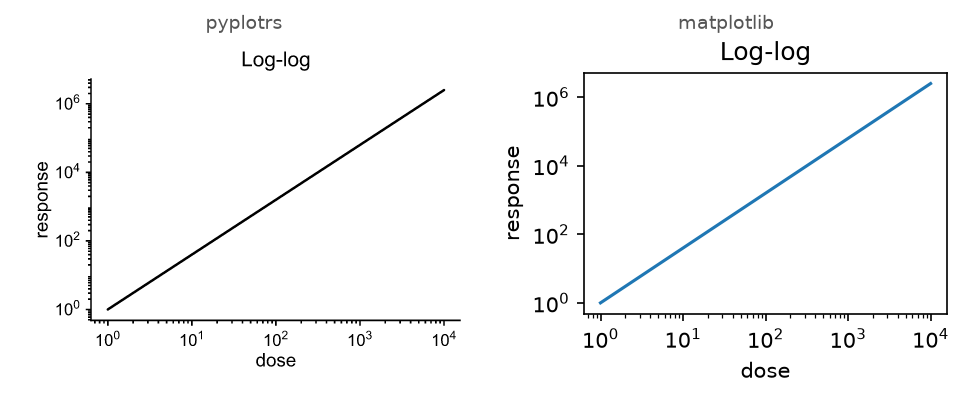

In [10]:
# A log-log axis: `set(xscale=...)` versus `set_xscale(...)`.
decades = [10 ** (i / 8) for i in range(33)]

fig_pp, ax = pp.subplots(figsize=SIZE_PT)
ax.line(decades, [v ** 1.6 for v in decades])
ax.set(title="Log-log", xlabel="dose", ylabel="response",
       xscale="log", yscale="log")

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
ax.plot(decades, [v ** 1.6 for v in decades])
ax.set(title="Log-log", xlabel="dose", ylabel="response")
ax.set_xscale("log")
ax.set_yscale("log")

compare(fig_pp, fig_mp)

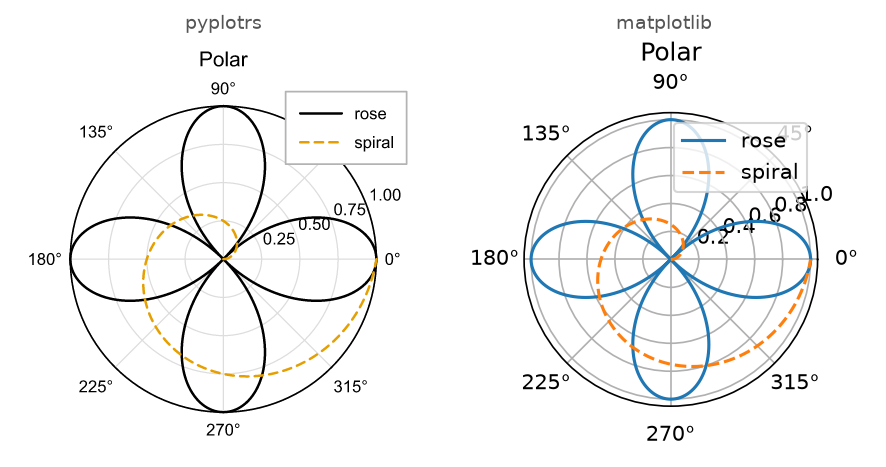

In [11]:
# Polar. `projection=` is a keyword on `subplots`, not a `subplot_kw` dict,
# and the mark is `plot` here because there is no `line`/`plot` ambiguity.
angles = [i * math.pi / 180 for i in range(361)]
rose = [abs(math.cos(2 * a)) for a in angles]
spiral = [a / (2 * math.pi) for a in angles]

fig_pp, ax = pp.subplots(projection="polar", figsize=(200, 200))
ax.plot(angles, rose, label="rose")
ax.plot(angles, spiral, label="spiral", linestyle="dashed")
ax.set(title="Polar")
ax.legend()

fig_mp, ax = plt.subplots(subplot_kw={"projection": "polar"},
                          figsize=pt2in((200, 200)), **CONSTRAINED)
ax.plot(angles, rose, label="rose")
ax.plot(angles, spiral, label="spiral", linestyle="dashed")
ax.set(title="Polar")
ax.legend()

compare(fig_pp, fig_mp)

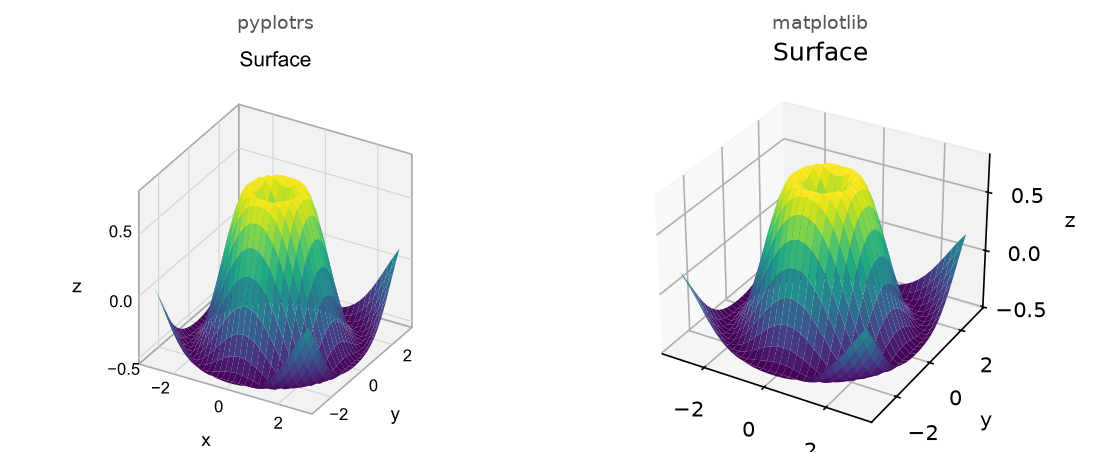

In [12]:
# 3D. `plot_surface` is `surface`; the projection keyword is the same idea.
grid = [[-3 + 6 * i / 28 for i in range(29)] for _ in range(29)]
X = grid
Y = [[-3 + 6 * j / 28 for _ in range(29)] for j in range(29)]
Z = [[math.sin(math.hypot(x, y) * 1.6) * math.exp(-0.25 * math.hypot(x, y))
      for x, y in zip(row_x, row_y)] for row_x, row_y in zip(X, Y)]

fig_pp, ax = pp.subplots(projection="3d", figsize=(250, 200))
ax.surface(X, Y, Z, cmap="viridis")
ax.set(title="Surface", xlabel="x", ylabel="y", zlabel="z")

fig_mp = plt.figure(figsize=pt2in((250, 200)), **CONSTRAINED)
ax = fig_mp.add_subplot(projection="3d")
ax.plot_surface(np.array(X), np.array(Y), np.array(Z), cmap="viridis")
ax.set(title="Surface", xlabel="x", ylabel="y", zlabel="z")

compare(fig_pp, fig_mp)

That 3D surface is the one comparison where the difference is structural rather
than cosmetic. matplotlib's 3D axes rasterize; pyplotrs projects the surface to
2D paths, so saving that figure as PDF or SVG gives **editable vector geometry**,
and saving it as `.html` gives an interactive Canvas2D viewer you can spin.
[More on that in the output notebook](08_output_and_performance.ipynb).

## The errors know what you meant

Porting a script mostly means running it and reading the failures, so the
failures were written to be worth reading. Every matplotlib name that pyplotrs
deliberately does not have raises with its replacement spelled out:

In [13]:
fig, ax = pp.subplots()

for attempt in ("ax.plot(t, sine)",
                "ax.set_xlabel('x')",
                "ax.set_xlim(0, 1)",
                "ax.tick_params(direction='in')",
                "fig.savefig('out.png')",
                "fig.tight_layout()"):
    try:
        eval(attempt, {"ax": ax, "fig": fig, "t": t, "sine": sine})
    except AttributeError as exc:
        print(f"{attempt}\n  → {str(exc).splitlines()[1].strip()}\n")

ax.plot(t, sine)
  → ax.line(x, y)

ax.set_xlabel('x')
  → ax.set(xlabel="...")

ax.set_xlim(0, 1)
  → ax.set(xlim=(lo, hi))

ax.tick_params(direction='in')
  → ax.set(tick_direction=..., tick_length=...)

fig.savefig('out.png')
  → fig.save("out.pdf")

fig.tight_layout()
  → nothing - layout is solved once, before anything is drawn



No aliasing: `plot` is not quietly forwarded to `line`, and the `set_*` family
is not quietly folded into `set()`. The renames are the argument the API is
making, so they fail loudly once instead of hiding forever.

## Colors

Everything matplotlib accepts, plus one improvement:

```python
ax.line(xs, ys, color="C2")                  # index THIS theme's palette
ax.line(xs, ys, color="steelblue")           # CSS / matplotlib color name
ax.line(xs, ys, color="#4682b4")             # hex
ax.line(xs, ys, color=(0.27, 0.51, 0.71))    # floats in 0-1, matplotlib style
ax.line(xs, ys, color=(70, 130, 180))        # bytes in 0-255, the native form
```

`"C0"`…`"Cn"` indexes the *active theme's* palette rather than a fixed global
cycle, so restyling a figure moves every `"C3"` in it at once.

## What pyplotrs gives you that matplotlib does not

The headline is text. matplotlib's SVG backend converts every label to a path by
default (`svg.fonttype = "path"`), so the words in the file are no longer words.
pyplotrs embeds a subset of the real font and writes real `<text>`:

In [14]:
import re

out = SCRATCH

fig_pp, ax = pp.subplots(figsize=SIZE_PT)
ax.line(t, sine, label="sin")
ax.legend()
ax.set(title="Selectable text", xlabel="time (s)", ylabel="amplitude")
fig_pp.save(str(out / "pyplotrs.svg"))
fig_pp.save(str(out / "pyplotrs.pdf"))

fig_mp, ax = plt.subplots(figsize=pt2in(), **CONSTRAINED)
ax.plot(t, sine, label="sin")
ax.legend()
ax.set(title="Selectable text", xlabel="time (s)", ylabel="amplitude")
fig_mp.savefig(out / "matplotlib.svg")
fig_mp.savefig(out / "matplotlib.pdf")
plt.close(fig_mp)

for name in ("pyplotrs", "matplotlib"):
    svg = (out / f"{name}.svg").read_text()
    labels = re.findall(r"<text[^>]*>([^<]*)</text>", svg)
    print(f"{name:<11} {len(labels):>2} <text> elements  "
          f"{len(re.findall(r'<path', svg)):>3} <path> elements")
    if labels:
        print(f"{'':<11} text still reads: {labels[-3:]}")

pyplotrs    14 <text> elements   16 <path> elements
            text still reads: ['time (s)', 'amplitude', 'sin']
matplotlib   0 <text> elements   38 <path> elements


The same holds in PDF, where both libraries keep text as text but pyplotrs
embeds and subsets the actual outline font rather than leaning on a Type 3
description, so the label survives a round trip through Illustrator. The rest of
the list:

- **Self-contained HTML output** — one file, no network, selectable text, and an
  interactive Canvas2D viewer for 3D.
- **3D that stays vector.** Surfaces and lines project to editable 2D paths
  rather than a rasterized inset.
- **`$…$` math with no LaTeX installation**, typeset from the math font's
  OpenType MATH table and left as real text in the output.
- **The GIL is released during export**, so a `ThreadPoolExecutor` over figures
  actually runs in parallel.
- **Export is faster**, usually by a lot — that is
  [its own notebook](08_output_and_performance.ipynb).

## What is not here

- The pyplot state machine, interactive backends, `show()`, and event/widget
  handling. pyplotrs makes files, not windows.
- `rcParams` and `style.use` — a `Theme` is an argument instead.
- The artist tree. There are no `Line2D` objects to fetch and mutate after the
  fact: a mark is recorded when you call it and rendered at `save()`.
- matplotlib's long tail of specialized marks. What is here is in
  [plot types](03_plot_types.ipynb); if something you rely on is missing, an
  issue is the right place for it.

## A porting checklist

1. `import pyplotrs as pp` and delete `plt.show()`.
2. Replace module-level `plt.plot` / `plt.xlabel` / `plt.savefig` with the
   `fig, ax = pp.subplots()` form.
3. `ax.plot` → `ax.line` (2D only).
4. Collapse every `ax.set_*` call into one `ax.set(...)`.
5. `fig.savefig(...)` → `fig.save(...)`; drop `fig.tight_layout()`.
6. `scatter(s=...)` → `size=...` (or `markersize=`, a diameter).
7. Replace `plt.style.use(...)` / `rcParams` with `theme=`.
8. Multiply your `figsize` by 72, or pass `units="in"` and keep the numbers.

Then run it: anything left over raises an `AttributeError` that names its own
replacement.